## Generate plots
- Eligible datasets:
    - data/preacq-data/beacon-plotting-data-eels
    - data/preacq-data/beacon-plotting-data-pfm


## fig 2

In [3]:
## load data
# read files
import pickle
import numpy as np

def read_pickle_al(file_path: str) -> dict:
    with open(file_path, "rb") as f:
        pkl_data_al = pickle.load(f)
    return pkl_data_al




In [ ]:
file_path_al_ei_eels = "beacon-plotting-data-eels/dkl-EI/Active_learning_statistics-300-ei.pkl"
file_path_al_ei_pfm = "beacon-plotting-data-pfm/dkl-EI/Active_learning_statistics-300-ei.pkl"

path_pkl_specific_bo_step_eels = "data/preacq-data/beacon-plotting-data-eels/dkl-bn/predictions_BO_step299.pkl"
path_pkl_specific_bo_step_pfm = "data/preacq-data/beacon-plotting-data-eels/dkl-EI/predictions_BO_step0.pkl"


pkl_data_al_ei_eels = read_pickle_al(file_path=file_path_al_ei_eels)
pkl_data_al_ei_pfm = read_pickle_al(file_path=file_path_al_ei_pfm)

pkl_data_step_eels = read_pickle_al(file_path= path_pkl_specific_bo_step_eels)
pkl_data_step_pfm = read_pickle_al(file_path= path_pkl_specific_bo_step_pfm)



In [5]:
def get_img(pkl_data_al: dict):
    img =  np.asarray(pkl_data_al["img"]) 
    return img

def get_scalarizer_img(data_bo_step: dict):
    scal_img = data_bo_step['true_scalarizer_img']
    return scal_img
    

In [6]:
img_eels = get_img(pkl_data_al_ei_eels)
scalarizer_eels = get_scalarizer_img(pkl_data_step_eels)
pixel_size_eels_nm = 1.60450073

img_pfm = get_img(pkl_data_al_ei_pfm)
scalarizer_pfm = get_scalarizer_img(pkl_data_step_pfm)
scan_um = 1.7
full_px = 100
crop_px = 60
display_px = crop_px - 16 + 1  # 45
pixel_size_pfm_nm = ((scan_um / full_px) * (crop_px / display_px))*1000



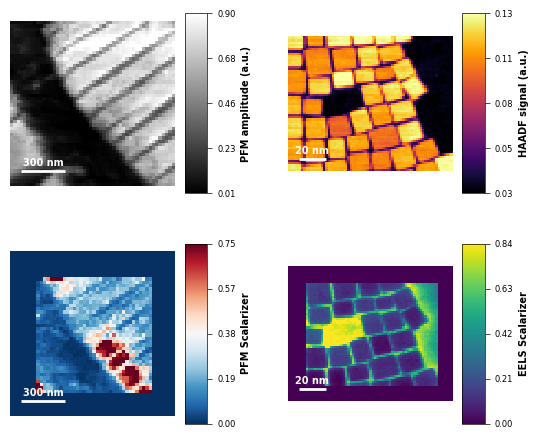

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np

def add_scalebar(ax, pixel_size_nm, fraction=0.25, color="white", lw=2, fontsize=7, bar_nm_fixed=None):
    h, w = ax.get_images()[0].get_array().shape[:2]
    bar_nm = bar_nm_fixed if bar_nm_fixed is not None else round((w * fraction * pixel_size_nm) / 50) * 50
    bar_px = bar_nm / pixel_size_nm
    x0, y0 = 0.06 * w, 0.90 * h
    ax.plot([x0, x0 + bar_px], [y0, y0], color=color, lw=lw, solid_capstyle="butt")
    label = f"{bar_nm:.0f} nm" if bar_nm < 1000 else f"{bar_nm/1000:.1f} µm"
    ax.text(x0 + bar_px / 2, y0 - 0.02 * h, label,
            color=color, ha="center", va="bottom", fontsize=fontsize, fontweight="bold")

def add_colorbar(fig, ax, im, label="", fontsize=7):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cb = fig.colorbar(im, cax=cax)
    cb.set_label(label, fontsize=fontsize, fontweight="bold", labelpad=4)
    cb.ax.tick_params(labelsize=fontsize - 1, width=0.5)
    cb.outline.set_linewidth(0.5)
    vmin, vmax = im.get_clim()
    cb.set_ticks(np.linspace(vmin, vmax, 5))
    cb.set_ticklabels([f"{v:.2f}" for v in np.linspace(vmin, vmax, 5)])
    return cb

# ── global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 7,
    "figure.facecolor": "white",
    "axes.facecolor": "black",
})

# ── KEY FIX: use gridspec with equal row/col ratios and fixed subplot size ────
# Each image panel is 1.8" x 1.8"; colorbar adds ~0.25"; gaps add ~0.4"
# Total width  ≈ 2 * (1.8 + 0.25) + 0.8 gap = ~4.9"  → use 5.5" for margin
# Total height ≈ 2 * 1.8 + 0.6 gap = ~4.2"            → use 4.5" for margin

panel_size = 1.8          # inches — each image square
cbar_frac  = 0.25         # inches — colorbar width per panel
hgap       = 0.65         # inches — horizontal gap between columns
vgap       = 0.50         # inches — vertical gap between rows
left_margin, right_margin = 0.15, 0.15
top_margin,  bot_margin   = 0.25, 0.15

fig_w = left_margin + 2 * panel_size + 2 * cbar_frac + hgap + right_margin
fig_h = top_margin  + 2 * panel_size + vgap + bot_margin

fig = plt.figure(figsize=(fig_w, fig_h))

# Build a gridspec where every image column has the same width
# Layout per row: [image | cbar | gap | image | cbar]
# We encode this as 5 columns with explicit widths
col_widths = [panel_size, cbar_frac, hgap, panel_size, cbar_frac]
row_heights = [panel_size, vgap, panel_size]   # row0, gap-row, row1

gs = gridspec.GridSpec(
    3, 5,
    figure=fig,
    width_ratios=col_widths,
    height_ratios=row_heights,
    left=left_margin / fig_w,
    right=1 - right_margin / fig_w,
    top=1 - top_margin / fig_h,
    bottom=bot_margin / fig_h,
    wspace=0.12,   # spacing handled by explicit gap columns/rows
    hspace=0,
)

# Image axes (row indices 0 and 2; col indices 0 and 3)
ax00 = fig.add_subplot(gs[0, 0])   # (a) top-left
ax01 = fig.add_subplot(gs[0, 3])   # (b) top-right
ax10 = fig.add_subplot(gs[2, 0])   # (c) bottom-left
ax11 = fig.add_subplot(gs[2, 3])   # (d) bottom-right

# Colorbar axes (adjacent to each image)
cax00 = fig.add_subplot(gs[0, 1])
cax01 = fig.add_subplot(gs[0, 4])
cax10 = fig.add_subplot(gs[2, 1])
cax11 = fig.add_subplot(gs[2, 4])

axes_img  = [ax00,  ax01,  ax10,  ax11]
axes_cbar = [cax00, cax01, cax10, cax11]

panels = [
    (ax00, img_pfm,         pixel_size_pfm_nm,  "PFM amplitude (a.u.)", "gray",    None),
    (ax01, img_eels,        pixel_size_eels_nm, "HAADF signal (a.u.)",  "inferno", 20),
    (ax10, scalarizer_pfm,  pixel_size_pfm_nm,  "PFM Scalarizer",        "RdBu_r",  None),
    (ax11, scalarizer_eels, pixel_size_eels_nm, "EELS Scalarizer",      "viridis", 20),
]

labels = ["a", "b", "c", "d"]

for i, ((ax, img, px, cb_label, cmap, bar_nm_fixed), cax, letter) in enumerate(
        zip(panels, axes_cbar, labels)):

    vmin, vmax = np.percentile(img, [2, 98])
    im = ax.imshow(img, cmap=cmap, interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.axis("off")
    add_scalebar(ax, px, bar_nm_fixed=bar_nm_fixed)

    # ── colorbar in dedicated axes (no divider needed — size is pre-set) ──
    cb = fig.colorbar(im, cax=cax)
    cb.set_label(cb_label, fontsize=7, fontweight="bold", labelpad=4)
    cb.ax.tick_params(labelsize=6, width=0.5)
    cb.outline.set_linewidth(0.5)
    cb.set_ticks(np.linspace(vmin, vmax, 5))
    cb.set_ticklabels([f"{v:.2f}" for v in np.linspace(vmin, vmax, 5)])

    # ── panel label (a / b / c / d) in top-left corner ───────────────────
    # ax.text(0.02, 0.98, letter,
    #         transform=ax.transAxes,
    #         fontsize=9, fontweight="bold", color="white",
    #         va="top", ha="left",
    #         bbox=dict(boxstyle="round,pad=0.15", fc="none", ec="none"))

fig.savefig("fig2.pdf", dpi=600, bbox_inches="tight")
fig.savefig("fig2.png", dpi=600, bbox_inches="tight")
plt.show()

## fig 2b)

In [8]:
## Fig 2

# load img_pfm and pfm_scalarizer and spectrum
# pixel_size_pfm


# load img_eels and eels_scalarizer
# pixel_size_eels


# figure with 6 subplots - 2*3

# imshow(img_pfm) and imshow(pfm_scalrizers) --> top and bottom
# have sclaebar

# imshow(img_eels) and imshow(eels_scalrizers) --> top and bottom
# have scalebar

# about the plot - less clutter and paper ready with good visibilty and font style
# cmap on simshow -> ?
# axis - not needed
# colorbar - yes for each
# colorbar index - bold etc --> 
# title - no title
#





## fig 3

In [10]:
file_path_al_ei_pfm = "beacon-plotting-data-pfm/dkl-EI/Active_learning_statistics-300-ei.pkl"
file_path_al_mu_pfm = "beacon-plotting-data-pfm/dkl-MU(high-beta-UCB)/Active_learning_statistics-300-mu.pkl"
file_path_al_bn_pfm = "beacon-plotting-data-pfm/dkl-bn/Active_learning_statistics-300-bn.pkl"

pkl_data_al_ei = read_pickle_al(file_path=file_path_al_ei_pfm)
pkl_data_al_mu = read_pickle_al(file_path=file_path_al_mu_pfm)
pkl_data_al_bn = read_pickle_al(file_path=file_path_al_bn_pfm)

In [11]:
def get_acq_ccords_seed_indices_and_t(pkl_data_al: dict):
    indices_all = np.asarray(pkl_data_al["indices_all"])          # (N, 2)
    acq_idx = np.asarray(pkl_data_al["acquired_order"], dtype=int)  # (T,)
    acq_coords = indices_all[acq_idx]                             # (T, 2)
    t = np.arange(len(acq_coords))
    
    # Seeds
    seed_indices = np.asarray(pkl_data_al["seed_indices"], dtype=int)
    seed_coords = indices_all[seed_indices]                       # (S, 2)
    
    # All patches (aligned with indices_all)
    patches_all = np.asarray(pkl_data_al["features"])             # (N, 16, 16)

    # Extract patches
    seed_patches = patches_all[seed_indices]                      # (S, 16, 16)
    acq_patches = patches_all[acq_idx]                             # (T, 16, 16)

    return t, acq_coords, seed_coords, acq_idx, seed_indices, patches_all, seed_patches, acq_patches

In [12]:
# prep results for 3 cases

## EI
t_ei, acq_coords_ei, seed_coords_ei, acq_idx_order_ei, seed_indices_ei, patches_all, seed_patches_ei, acq_patches_ei = get_acq_ccords_seed_indices_and_t(pkl_data_al_ei)


## UCB-MU
t_mu, acq_coords_mu, seed_coords_mu, acq_idx_order_mu, seed_indices_mu, patches_all, seed_patches_mu, acq_patches_mu  = get_acq_ccords_seed_indices_and_t(pkl_data_al_mu)


## Beacon
t_bn, acq_coords_bn, seed_coords_bn, acq_idx_order_bn, seed_indices_bn, patches_all, seed_patches_bn, acq_patches_bn   = get_acq_ccords_seed_indices_and_t(pkl_data_al_bn)


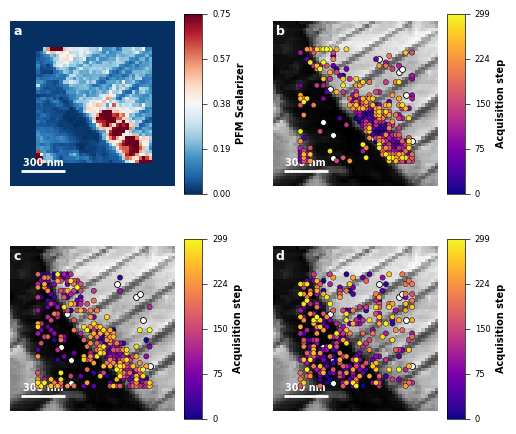

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import numpy as np

# ── prep trajectory data ──────────────────────────────────────────────────────
# acq_coords: shape (N, 2) with (row, col) → we plot as (col, row) = (x, y)
ei_y,  ei_x  = acq_coords_ei[:,  0], acq_coords_ei[:,  1]
mu_y,  mu_x  = acq_coords_mu[:, 0], acq_coords_mu[:, 1]
bn_y,  bn_x  = acq_coords_bn[:, 0], acq_coords_bn[:, 1]

seed_y_ei, seed_x_ei = seed_coords_ei[:, 0], seed_coords_ei[:, 1]
seed_y_mu, seed_x_mu = seed_coords_mu[:, 0], seed_coords_mu[:, 1]
seed_y_bn, seed_x_bn = seed_coords_bn[:, 0], seed_coords_bn[:, 1]

t_max = max(t_ei.max(), t_mu.max(), t_bn.max())

# ── helper: scalebar (reused from fig2) ──────────────────────────────────────
def add_scalebar(ax, pixel_size_nm, color="white", lw=2, fontsize=7,
                 bar_nm_fixed=None, fraction=0.25):
    h, w = ax.get_images()[0].get_array().shape[:2]
    bar_nm = (bar_nm_fixed if bar_nm_fixed is not None
              else round((w * fraction * pixel_size_nm) / 50) * 50)
    bar_px = bar_nm / pixel_size_nm
    x0, y0 = 0.06 * w, 0.90 * h
    ax.plot([x0, x0 + bar_px], [y0, y0], color=color, lw=lw,
            solid_capstyle="butt")
    label = f"{bar_nm:.0f} nm" if bar_nm < 1000 else f"{bar_nm/1000:.1f} µm"
    ax.text(x0 + bar_px / 2, y0 - 0.02 * h, label,
            color=color, ha="center", va="bottom",
            fontsize=fontsize, fontweight="bold")

# ── global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size":    7,
    "figure.facecolor": "white",
    "axes.facecolor":   "black",
})

# ── figure geometry (physical inches) ────────────────────────────────────────
panel_size  = 1.8    # image panel (square)
cbar_w      = 0.20   # colorbar column width
hgap        = 0.55   # horizontal gap between columns
vgap        = 0.45   # vertical gap between rows
lm, rm      = 0.15, 0.30   # left / right margin (extra right for shared cbar)
tm, bm      = 0.25, 0.15   # top  / bottom margin

# columns: img | cbar | gap | img | cbar
col_w  = [panel_size, cbar_w, hgap, panel_size, cbar_w]
# rows:   img | gap | img
row_h  = [panel_size, vgap, panel_size]

fig_w = lm + sum(col_w) + rm
fig_h = tm + sum(row_h) + bm

fig = plt.figure(figsize=(fig_w, fig_h))

gs = gridspec.GridSpec(
    3, 5,
    figure=fig,
    width_ratios=col_w,
    height_ratios=row_h,
    left   = lm / fig_w,
    right  = 1 - rm / fig_w,
    top    = 1 - tm / fig_h,
    bottom = bm / fig_h,
    wspace = 0.12,
    hspace = 0,
)

# image axes
ax_pfm = fig.add_subplot(gs[0, 0])   # (a) PFM scalarizer
ax_ei  = fig.add_subplot(gs[0, 3])   # (b) EI trajectory
ax_mu  = fig.add_subplot(gs[2, 0])   # (c) UCB-MU trajectory
ax_bn  = fig.add_subplot(gs[2, 3])   # (d) Beacon trajectory

# colorbar axes
cax_pfm  = fig.add_subplot(gs[0, 1])   # colorbar for (a) — PFM phase
# shared trajectory colorbar: spans both rows in the right cbar column
# cax_traj = fig.add_subplot(gs[0:3, 4]) # spans rows 0-2 (including gap row)

# ── (a) PFM scalarizer ───────────────────────────────────────────────────────
vmin_p, vmax_p = np.percentile(scalarizer_pfm, [2, 98])
im_pfm = ax_pfm.imshow(scalarizer_pfm, cmap="RdBu_r",
                        interpolation="nearest", vmin=vmin_p, vmax=vmax_p)
ax_pfm.axis("off")
add_scalebar(ax_pfm, pixel_size_pfm_nm)

cb_pfm = fig.colorbar(im_pfm, cax=cax_pfm)
cb_pfm.set_label("PFM Scalarizer", fontsize=7, fontweight="bold", labelpad=4)
cb_pfm.ax.tick_params(labelsize=6, width=0.5)
cb_pfm.outline.set_linewidth(0.5)
cb_pfm.set_ticks(np.linspace(vmin_p, vmax_p, 5))
cb_pfm.set_ticklabels([f"{v:.2f}" for v in np.linspace(vmin_p, vmax_p, 5)])

# ── scatter panels (b / c / d) ───────────────────────────────────────────────
cax_ei = fig.add_subplot(gs[0, 4])
cax_mu = fig.add_subplot(gs[2, 1])
cax_bn = fig.add_subplot(gs[2, 4])
traj_panels = [
    (ax_ei, img_pfm, ei_x, ei_y, t_ei, seed_x_ei, seed_y_ei, cax_ei),
    (ax_mu, img_pfm, mu_x, mu_y, t_mu, seed_x_mu, seed_y_mu, cax_mu),
    (ax_bn, img_pfm, bn_x, bn_y, t_bn, seed_x_bn, seed_y_bn, cax_bn),
]

for ax, bg, sx, sy, t, sdx, sdy, cax in traj_panels:
    ax.imshow(bg, cmap="gray", interpolation="nearest")
    ax.axis("off")
    add_scalebar(ax, pixel_size_pfm_nm)

    ax.scatter(
        sdx, sdy,
        s=18, c="white",
        edgecolors="black", linewidths=0.6,
        marker="o", zorder=3
    )

    sc = ax.scatter(
        sx, sy,
        c=t, cmap="plasma", vmin=0, vmax=t_max,
        s=14, marker="o",
        edgecolors="k", linewidths=0.3,
        zorder=4
    )

    # ── SAME STYLE AS PANEL (a) ─────────────────────
    cb = fig.colorbar(sc, cax=cax)
    cb.set_label("Acquisition step", fontsize=7,
                 fontweight="bold", labelpad=4)
    cb.ax.tick_params(labelsize=6, width=0.5)
    cb.outline.set_linewidth(0.5)

    ticks = np.linspace(0, t_max, 5)
    cb.set_ticks(ticks)
    cb.set_ticklabels([f"{v:.0f}" for v in ticks])

# ── shared trajectory colorbar ───────────────────────────────────────────────
# cb_traj = fig.colorbar(sc_last, cax=cax_traj)
# cb_traj.set_label("Acquisition step", fontsize=7, fontweight="bold", labelpad=4)
# cb_traj.ax.tick_params(labelsize=6, width=0.5)
# cb_traj.outline.set_linewidth(0.5)
# cb_traj.set_ticks(np.linspace(0, t_max, 5))
# cb_traj.set_ticklabels([f"{v:.0f}" for v in np.linspace(0, t_max, 5)])

# ── panel labels (a / b / c / d) ─────────────────────────────────────────────
for ax, letter in zip([ax_pfm, ax_ei, ax_mu, ax_bn], ["a", "b", "c", "d"]):
    ax.text(0.02, 0.98, letter,
            transform=ax.transAxes,
            fontsize=9, fontweight="bold", color="white",
            va="top", ha="left")

fig.savefig("fig3.pdf", dpi=600, bbox_inches="tight")
fig.savefig("fig3.png", dpi=600, bbox_inches="tight")
plt.show()

## fig 4

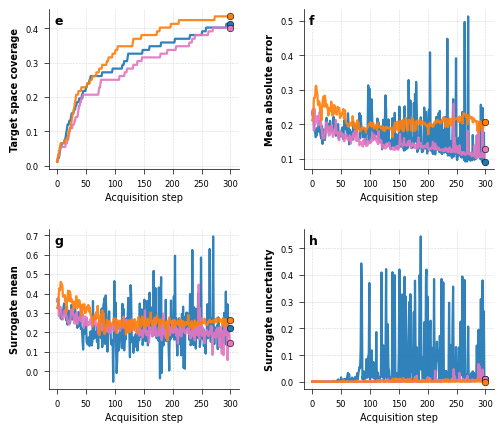

In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── consistent palette (matches fig3) ────────────────────────────────────────
colors = {
    "EI":     "#1f77b4",
    "MU":     "#e377c2",
    "Beacon": "#ff7f0e",
}
labels_display = {
    "EI": "EI",
    "MU": "UCB-MU",
    "Beacon": "Beacon",
}

data_sets = [
    ("EI",     t_ei, pkl_data_al_ei, acq_idx_order_ei),
    ("MU",     t_mu, pkl_data_al_mu, acq_idx_order_mu),
    ("Beacon", t_bn, pkl_data_al_bn, acq_idx_order_bn),
]

# ── target-space coverage (computed once) ────────────────────────────────────
def compute_observed_coverage(acquired_indices, true_img_flat, n_bins=100):
    t_min, t_max = true_img_flat.min(), true_img_flat.max()
    bins = np.linspace(t_min, t_max, n_bins + 1)
    true_hist, _ = np.histogram(true_img_flat, bins=bins)
    required_bins = set(np.where(true_hist > 0)[0])
    coverage_evolution, seen_bins = [], set()
    for idx in acquired_indices:
        bin_idx = np.digitize(true_img_flat[idx], bins) - 1
        if bin_idx in required_bins:
            seen_bins.add(bin_idx)
        coverage_evolution.append(len(seen_bins) / len(required_bins))
    return np.array(coverage_evolution)

# load true_img_flat from any pkl (same ground truth for all)
import pickle, os
_ref_file = os.path.join(
    "beacon-plotting-data-pfm/dkl-bn/out/"
    "Dataset_seed1_yl_beps.h5_BO_10_epochs100_budget_300_loop_area_ws16_20260210_221449/",
    "predictions_BO_step299.pkl"
)
with open(_ref_file, "rb") as f:
    _ref = pickle.load(f)
true_img_flat = _ref["true_scalarizer_img"].flatten()

coverage = {
    name: compute_observed_coverage(acq_idx, true_img_flat, n_bins=100)
    for name, _, _, acq_idx in data_sets
}

# ── panel definitions ─────────────────────────────────────────────────────────
panels = [
    {
        "key":    "coverage",
        "ylabel": "Target space coverage",
        "getter": lambda name, t, pkl, acq: (np.arange(len(coverage[name])), coverage[name]),
        "xlabel": "Acquisition step",
    },
    {
        "key":    "mae",
        "ylabel": "Mean absolute error",
        "getter": lambda name, t, pkl, acq: (t, pkl["mae"]),
        "xlabel": "Acquisition step",
    },
    {
        "key":    "mean",
        "ylabel": "Surrogate mean",
        "getter": lambda name, t, pkl, acq: (t, pkl["mean_y_pred_mean_al"]),
        "xlabel": "Acquisition step",
    },
    {
        "key":    "var",
        "ylabel": "Surrogate uncertainty",
        "getter": lambda name, t, pkl, acq: (t, pkl["mean_y_pred_variance_al"]),
        "xlabel": "Acquisition step",
    },
]

# ── figure geometry ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.size":        7,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
})

panel_w  = 1.9    # inches per plot
panel_h  = 1.6
hgap     = 0.65
vgap     = 0.60
lm, rm   = 0.55, 0.15
tm, bm   = 0.20, 0.45   # bm larger for shared x-label / legend

fig_w = lm + 2 * panel_w + hgap + rm
fig_h = tm + 2 * panel_h + vgap + bm

fig = plt.figure(figsize=(fig_w, fig_h))

col_w  = [panel_w, hgap, panel_w]
row_h  = [panel_h, vgap, panel_h]

gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    width_ratios=col_w,
    height_ratios=row_h,
    left   = lm / fig_w,
    right  = 1 - rm / fig_w,
    top    = 1 - tm / fig_h,
    bottom = bm / fig_h,
    wspace = 0,
    hspace = 0,
)

ax_positions = [(0, 0), (0, 2), (2, 0), (2, 2)]
axes = [fig.add_subplot(gs[r, c]) for r, c in ax_positions]
panel_labels = ["e", "f", "g", "h"]

# ── plot each panel ───────────────────────────────────────────────────────────
for ax, panel, letter in zip(axes, panels, panel_labels):

    for name, t, pkl, acq_idx in data_sets:
        x, y = panel["getter"](name, t, pkl, acq_idx)
        ax.plot(x, y,
                linewidth=1.6,
                color=colors[name],
                alpha=0.92,
                label=labels_display[name])
        # terminal dot
        ax.scatter(x[-1], y[-1],
                   color=colors[name], s=22,
                   edgecolors="k", linewidths=0.4, zorder=5)

    ax.set_ylabel(panel["ylabel"], fontsize=7, fontweight="bold", labelpad=4)
    ax.set_xlabel(panel["xlabel"], fontsize=7, labelpad=3)

    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=6, width=0.5)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(0.5)
    # 🔥 ADD LEGEND ONLY TO FIRST PANEL
    if letter == "a":
        ax.legend(
            loc="lower right",          # change if it overlaps data
            frameon=True,
            framealpha=0.9,
            edgecolor="lightgray",
            fontsize=6,
            handlelength=2.0,
            borderpad=0.3
        )
    # panel label
    ax.text(0.03, 0.97, letter,
            transform=ax.transAxes,
            fontsize=9, fontweight="bold", color="black",
            va="top", ha="left")

# ── shared legend below all panels ───────────────────────────────────────────
handles, lbls = axes[0].get_legend_handles_labels()
# ── shared legend below all panels ───────────────────────────────────────────
# Increase bm and nudge bbox_to_anchor down
# bm = 0.6   # was 0.45 — more room below panels for legend

# fig.legend(handles, lbls,
#            loc="lower center",
#            ncol=3,
#            bbox_to_anchor=(0.5, 0.01),   # was 0.02 — nudge down
#            frameon=True,
#            framealpha=0.9,
#            edgecolor="lightgray",
#            fontsize=7,
#            markerscale=1.2,
#            handlelength=2.0,
#            columnspacing=1.5)

fig.savefig("fig4.pdf", dpi=400, bbox_inches="tight")
fig.savefig("fig4.png", dpi=400, bbox_inches="tight")
plt.show()

## fig 5

In [15]:
import numpy as np

def _kmeans_numpy(X: np.ndarray, k: int, n_iters: int = 25, seed: int = 0):
    """
    Simple numpy k-means.
    X: (N, D) float
    Returns:
      labels: (N,) int in [0, k-1]
      centers: (k, D)
    """
    rng = np.random.default_rng(seed)
    N, D = X.shape

    # init centers from random points
    centers = X[rng.choice(N, size=k, replace=False)].copy()

    for _ in range(n_iters):
        # assign
        # dist^2 = ||x||^2 + ||c||^2 - 2 x·c
        x2 = np.sum(X * X, axis=1, keepdims=True)            # (N,1)
        c2 = np.sum(centers * centers, axis=1)[None, :]      # (1,k)
        d2 = x2 + c2 - 2.0 * (X @ centers.T)                 # (N,k)
        labels = np.argmin(d2, axis=1)                       # (N,)

        # update
        new_centers = centers.copy()
        for j in range(k):
            mask = (labels == j)
            if np.any(mask):
                new_centers[j] = X[mask].mean(axis=0)
            else:
                # empty cluster -> re-seed
                new_centers[j] = X[rng.integers(0, N)]
        centers = new_centers

    return labels, centers


def compute_patch_space_coverage(acq_idx, patches_all, k=80, embed_dim=32, seed=0, n_kmeans_iters=25):
    """
    Patch-space discovery curve (coverage vs step).
    - Clusters ALL patches once (discrete patch diversity).
    - Coverage(t) = fraction of clusters discovered by acquired patches up to t.

    acq_idx: (T,) indices into patches_all
    patches_all: (N, 16, 16) or (N, H, W[, C])
    """
    acq_idx = np.asarray(acq_idx, dtype=int)
    P = np.asarray(patches_all)

    # flatten patches -> (N, D)
    X = P.reshape(P.shape[0], -1).astype(np.float32)

    # normalize (important so intensity scale doesn't dominate)
    X = X - X.mean(axis=1, keepdims=True)
    denom = X.std(axis=1, keepdims=True) + 1e-8
    X = X / denom

    # cheap embedding to speed kmeans (random projection)
    rng = np.random.default_rng(seed)
    W = rng.normal(size=(X.shape[1], embed_dim)).astype(np.float32)
    Z = X @ W  # (N, embed_dim)

    # cluster all patches
    labels, _ = _kmeans_numpy(Z, k=k, n_iters=n_kmeans_iters, seed=seed)

    # which clusters exist at all?
    required_clusters = set(np.unique(labels).tolist())

    # step through acquisitions
    coverage = []
    seen = set()

    for idx in acq_idx:
        seen.add(int(labels[idx]))
        coverage.append(len(seen) / len(required_clusters))

    return np.asarray(coverage, dtype=float)

In [16]:
patches_all = np.asarray(pkl_data_al_bn["features"])

cover_ei_patch = compute_patch_space_coverage(acq_idx_order_ei, patches_all, k=100)
cover_mu_patch = compute_patch_space_coverage(acq_idx_order_mu, patches_all, k=100)
cover_bn_patch = compute_patch_space_coverage(acq_idx_order_bn, patches_all, k=100)

In [17]:
# ============================================================
# VAE-latent coverage (pyroVED) + plots (coverage, latent KDE/trajectory, losses)
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from pyroved.models import iVAE
from pyroved.trainers import SVItrainer

# --------------------------
# 0) Your inputs (assumed already defined)
# --------------------------
# patches_all: (N,16,16) from pkl_data_al_*["features"]
# acq_idx_order_ei, acq_idx_order_mu, acq_idx_order_bn : (T,)
# seed_indices_ei, seed_indices_mu, seed_indices_bn : (S,)  (optional but recommended)

# patches_all = np.asarray(pkl_data_al_bn["features"])  # (1225,16,16)


# --------------------------
# 1) Train pyroVED VAE once + get latent Z for ALL patches
# --------------------------
def train_pyroved_vae_and_encode(
    patches_all: np.ndarray,
    latent_dim: int = 2,
    epochs: int = 200,
    batch_size: int = 128,
    lr: float = 1e-3,
    scale_factor: float = 1.0,
    seed: int = 0,
    device: str | None = None,
):
    """
    Returns:
      Z: (N, latent_dim) latent means (mu / z_loc)
      loss_hist: list[float] (epoch losses; best-effort)
      vae, trainer, device  (in case you want them)
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    P = np.asarray(patches_all, dtype=np.float32)
    assert P.ndim == 3 and P.shape[1:] == (16, 16), f"Expected (N,16,16), got {P.shape}"

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # VAE: use gaussian decoder for continuous-valued patches
    vae = iVAE(
        data_dim=(16, 16),
        latent_dim=latent_dim,
        invariances=None,      # vanilla VAE
        sampler_d="gaussian",  # continuous pixels
        sigmoid_d=False,
    )

    # If pyroVED model is a torch module (usually is), move to device
    try:
        vae = vae.to(device)
    except Exception:
        pass

    trainer = SVItrainer(vae, lr=lr)

    x = torch.tensor(P, device=device)  # (N,16,16)
    dl = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(x),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    loss_hist = []

    for ep in tqdm(range(epochs), desc="Training pyroVED VAE"):
        epoch_loss = 0.0
        n = 0

        for (xb,) in dl:
            # IMPORTANT: scale_factor is per-step weight; you can pass it via trainer.svi.step
            # Some pyroVED versions implement scale_factor through the model/guide.
            # We'll keep it simple: just log the base loss returned.
            epoch_loss += trainer.svi.step(xb)
            n += 1

        epoch_loss /= max(n, 1)
        loss_hist.append(epoch_loss)

    # Encode all patches -> (z_loc, z_scale) (most pyroVED versions)
    with torch.no_grad():
        # Many pyroVED versions accept encode(x, batch_size=...)
        try:
            z_loc, z_scale = vae.encode(x, batch_size=256)
        except TypeError:
            # fallback: no batch_size kwarg
            z_loc, z_scale = vae.encode(x)

    Z = z_loc.detach().cpu().numpy().astype(np.float32)  # (N, latent_dim)
    return Z, loss_hist, vae, trainer, device


# --------------------------
# 2) Simple numpy k-means + coverage-from-labels (same as your earlier idea)
# --------------------------
def kmeans_numpy(X: np.ndarray, k: int, n_iters: int = 25, seed: int = 0):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float32)
    N, D = X.shape
    centers = X[rng.choice(N, size=k, replace=False)].copy()

    for _ in range(n_iters):
        x2 = np.sum(X * X, axis=1, keepdims=True)
        c2 = np.sum(centers * centers, axis=1)[None, :]
        d2 = x2 + c2 - 2.0 * (X @ centers.T)
        labels = np.argmin(d2, axis=1)

        new_centers = centers.copy()
        for j in range(k):
            m = (labels == j)
            if np.any(m):
                new_centers[j] = X[m].mean(axis=0)
            else:
                new_centers[j] = X[rng.integers(0, N)]
        centers = new_centers

    return labels, centers


def coverage_from_labels(acq_idx, labels_all, required=None):
    acq_idx = np.asarray(acq_idx, dtype=int)
    if required is None:
        required = set(np.unique(labels_all).tolist())

    seen = set()
    cov = []
    for idx in acq_idx:
        seen.add(int(labels_all[idx]))
        cov.append(len(seen) / len(required))
    return np.asarray(cov, dtype=float)


# --------------------------
# 3) Plot helpers: coverage, latent KDE+trajectory, losses
# --------------------------
colors = {"EI": "#1f77b4", "MU": "#e377c2", "Beacon": "#ff7f0e"}

def plot_coverages(cover_dict, title="VAE Latent Space Discovery: Coverage vs. Step"):
    plt.figure(figsize=(10, 6))

    plt.plot(cover_ei, label="EI", color=colors["EI"], linewidth=3)
    plt.plot(cover_mu, label="MU", color=colors["MU"], linewidth=3)
    plt.plot(cover_bn, label="Beacon", color=colors["Beacon"], linewidth=3)

    plt.title("VAE Latent Space Discovery: Coverage vs. Acquisition Step", fontsize=14, fontweight="bold")
    plt.xlabel("Acquisition Step (Time Order)")
    plt.ylabel("Fraction of Latent Clusters Discovered")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def kde2d_density(Z2, gridsize=200, bandwidth=None, margin=0.05):
    """
    KDE via sklearn if available; otherwise falls back to 2D histogram density.
    """
    Z2 = np.asarray(Z2, dtype=np.float32)
    x, y = Z2[:, 0], Z2[:, 1]

    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(y.min()), float(y.max())
    dx, dy = xmax - xmin, ymax - ymin
    xmin -= margin * dx; xmax += margin * dx
    ymin -= margin * dy; ymax += margin * dy

    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, gridsize),
        np.linspace(ymin, ymax, gridsize),
        indexing="xy",
    )
    grid = np.column_stack([xx.ravel(), yy.ravel()])

    if bandwidth is None:
        bandwidth = 0.15 * np.sqrt(dx * dx + dy * dy) / 2.0
        bandwidth = max(float(bandwidth), 1e-3)

    try:
        from sklearn.neighbors import KernelDensity
        kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian")
        kde.fit(Z2)
        log_d = kde.score_samples(grid)
        dens = np.exp(log_d).reshape(xx.shape)
        return xx, yy, dens
    except Exception:
        H, xedges, yedges = np.histogram2d(x, y, bins=gridsize, density=True)
        xc = 0.5 * (xedges[:-1] + xedges[1:])
        yc = 0.5 * (yedges[:-1] + yedges[1:])
        xx2, yy2 = np.meshgrid(xc, yc, indexing="xy")
        dens2 = H.T
        return xx2, yy2, dens2


def plot_latent_kde_and_trajectory(
    Z2,
    acq_idx,
    seed_idx=None,
    title="Latent space: KDE(all) + selected trajectory",
    gridsize=200,
    bandwidth=None,
    show_path=True,
    method_color="black",
):
    Z2 = np.asarray(Z2, dtype=np.float32)
    acq_idx = np.asarray(acq_idx, dtype=int)

    xx, yy, dens = kde2d_density(Z2, gridsize=gridsize, bandwidth=bandwidth)

    plt.figure(figsize=(9, 7))

    # --- KDE background ---
    plt.contourf(xx, yy, dens, levels=40)

    # --- All latent points (background cloud) ---
    plt.scatter(
        Z2[:, 0], Z2[:, 1],
        s=12, alpha=0.25,
        label="All patches"
    )

    # --- Selected trajectory ---
    sel = Z2[acq_idx]
    t = np.arange(len(sel))

    sc = plt.scatter(
        sel[:, 0], sel[:, 1],
        c=t,
        s=40,
        cmap="plasma",
        edgecolors="k",
        linewidths=0.4,
        zorder=3,
        label="Acquired"
    )

    if show_path and len(sel) > 1:
        plt.plot(
            sel[:, 0], sel[:, 1],
            color=method_color,
            linewidth=1.5,
            alpha=0.8,
            zorder=2
        )

    # --- Start / End markers ---
    plt.scatter(
        sel[0, 0], sel[0, 1],
        s=180, marker="*",
        edgecolors="k",
        zorder=4,
        label="Start"
    )

    plt.scatter(
        sel[-1, 0], sel[-1, 1],
        s=180, marker="P",
        edgecolors="k",
        zorder=4,
        label="End"
    )

    # --- Seed points ---
    if seed_idx is not None:
        seed_idx = np.asarray(seed_idx, dtype=int)
        seeds = Z2[seed_idx]
        plt.scatter(
            seeds[:, 0], seeds[:, 1],
            s=70,
            marker="o",
            facecolors="white",
            edgecolors="black",
            linewidths=1,
            zorder=5,
            label="Seeds"
        )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    plt.grid(alpha=0.2)

    plt.colorbar(sc, label="Acquisition Step")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_loss_curve(loss_hist, title="pyroVED VAE training loss (epoch)"):
    plt.figure(figsize=(10, 6))
    plt.plot(loss_hist, linewidth=2)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (as reported by trainer, if available)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------
# 4) RUN: Train once -> Z -> cluster once -> 3 coverages -> plots
# --------------------------
# 4.1 Train & encode
Z2, loss_hist, vae, trainer, device = train_pyroved_vae_and_encode(
    patches_all,
    latent_dim=2,
    epochs=200,
    batch_size=128,
    lr=1e-3,
    scale_factor=1.0,  # if you see KL collapse later, try e.g. 0.2 or warmup externally
    seed=0,
)

# 4.2 Cluster ALL patches in latent space (once)
labels_all, centers = kmeans_numpy(Z2, k=80, n_iters=25, seed=0)
required = set(np.unique(labels_all).tolist())

# 4.3 Coverage curves (same labels for fairness)
cover_ei_vae = coverage_from_labels(acq_idx_order_ei, labels_all, required)
cover_mu_vae = coverage_from_labels(acq_idx_order_mu, labels_all, required)
cover_bn_vae = coverage_from_labels(acq_idx_order_bn, labels_all, required)

# 4.4 Plots
# plot_coverages({"EI": cover_ei_vae, "MU": cover_mu, "Beacon": cover_bn})



Training pyroVED VAE:   0%|          | 0/200 [00:00<?, ?it/s]

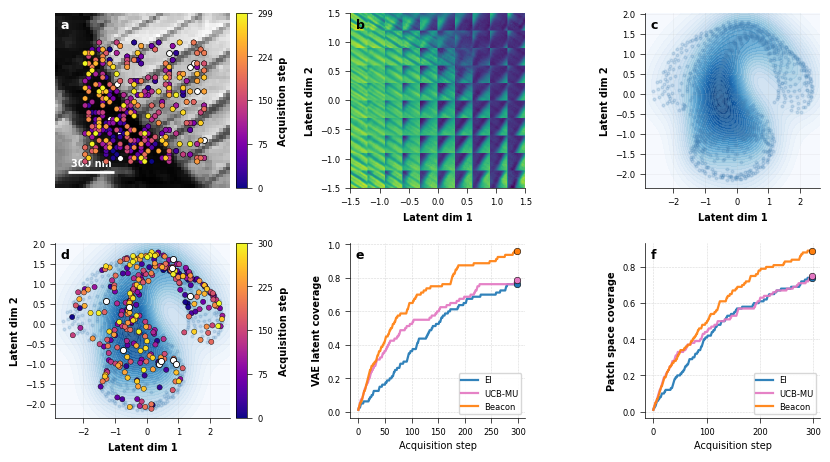

In [24]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── consistent palette ────────────────────────────────────────────────────────
colors = {"EI": "#1f77b4", "MU": "#e377c2", "Beacon": "#ff7f0e"}
labels_display = {"EI": "EI", "MU": "UCB-MU", "Beacon": "Beacon"}

plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.size":        7,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
})

# ── helpers ───────────────────────────────────────────────────────────────────
def add_scalebar(ax, pixel_size_nm, color="white", lw=2, fontsize=7,
                 bar_nm_fixed=None, fraction=0.25):
    h, w = ax.get_images()[0].get_array().shape[:2]
    bar_nm = (bar_nm_fixed if bar_nm_fixed is not None
              else round((w * fraction * pixel_size_nm) / 50) * 50)
    bar_px = bar_nm / pixel_size_nm
    x0, y0 = 0.06 * w, 0.90 * h
    ax.plot([x0, x0 + bar_px], [y0, y0], color=color, lw=lw, solid_capstyle="butt")
    label = f"{bar_nm:.0f} nm" if bar_nm < 1000 else f"{bar_nm/1000:.1f} µm"
    ax.text(x0 + bar_px / 2, y0 - 0.02 * h, label,
            color=color, ha="center", va="bottom",
            fontsize=fontsize, fontweight="bold")

def style_scatter_ax(ax):
    ax.tick_params(labelsize=6, width=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_linewidth(0.5)
    ax.grid(alpha=0.2, linewidth=0.4)

def style_line_ax(ax):
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=6, width=0.5)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_linewidth(0.5)

def panel_label(ax, letter, color="black"):
    ax.text(0.03, 0.97, letter,
            transform=ax.transAxes,
            fontsize=9, fontweight="bold", color=color,
            va="top", ha="left")

# ── pre-compute KDE once (shared by panels c and d) ──────────────────────────
xx, yy, dens = kde2d_density(Z2, gridsize=200)

# ── figure geometry ───────────────────────────────────────────────────────────
panel_sq  = 1.75   # all panels same size (square)
hgap      = 1.2  # horizontal gap
vgap      = 0.55   # vertical gap
cbar_w    = 0.18   # colorbar for panel (d) only
lm, rm    = 0.45, 0.20
tm, bm    = 0.20, 0.55   # bm for shared legend

fig_w = lm + 3 * panel_sq + 2 * hgap + cbar_w + rm
fig_h = tm + 2 * panel_sq + vgap + bm

fig = plt.figure(figsize=(fig_w, fig_h))

# 5 columns: img | gap | img | gap | img+cbar
# cbar lives in a thin column only next to col 4 (panel d)
col_w = [panel_sq, hgap, panel_sq, hgap, panel_sq, cbar_w]
row_h = [panel_sq, vgap, panel_sq]

gs = gridspec.GridSpec(
    3, 6,
    figure=fig,
    width_ratios=col_w,
    height_ratios=row_h,
    left   = lm / fig_w,
    right  = 1 - rm / fig_w,
    top    = 1 - tm / fig_h,
    bottom = bm / fig_h,
    wspace = 0,
    hspace = 0,
)

# axes
ax_a = fig.add_subplot(gs[0, 0])   # (a) real-space trajectory
ax_b = fig.add_subplot(gs[0, 2])   # (b) VAE manifold
ax_c = fig.add_subplot(gs[0, 4])   # (c) latent KDE only
ax_d = fig.add_subplot(gs[2, 0])   # (d) latent KDE + trajectory
cax_d= fig.add_subplot(gs[2, 1])   # colorbar for (d) — sits in gap col, tight
ax_e = fig.add_subplot(gs[2, 2])   # (e) VAE latent coverage
ax_f = fig.add_subplot(gs[2, 4])   # (f) patch space coverage

# ── NOTE: cax_d uses the hgap column — adjust pad via inset if too wide ───────
# Alternatively use a figure-level axes for precise sizing:
cax_d.remove()
cbar_x = (lm + panel_sq + hgap * 0.05) / fig_w          # just right of ax_d
cbar_y = bm / fig_h
cax_d  = fig.add_axes([cbar_x, cbar_y,
                        0.013,
                        panel_sq / fig_h])

# ═══════════════════════════════════════════════════════════════════════════════
# (a) Real-space trajectory — Beacon
# ═══════════════════════════════════════════════════════════════════════════════
bn_y, bn_x         = acq_coords_bn[:, 0], acq_coords_bn[:, 1]
seed_y_bn, seed_x_bn = seed_coords_bn[:, 0], seed_coords_bn[:, 1]
t_max = t_bn.max()

ax_a.imshow(img_pfm, cmap="gray", interpolation="nearest")
ax_a.axis("off")
add_scalebar(ax_a, pixel_size_pfm_nm)
ax_a.scatter(seed_x_bn, seed_y_bn,
             s=18, c="white", edgecolors="black", linewidths=0.6,
             marker="o", zorder=3)
ax_a.scatter(bn_x, bn_y,
             c=t_bn, cmap="plasma", vmin=0, vmax=t_max,
             s=14, marker="o", edgecolors="k", linewidths=0.3, zorder=4)
panel_label(ax_a, "a", color="white")

# ── colorbar for (a) — acquisition step ──────────────────────────────────────
# in panel (a) block — capture the scatter for colorbar
sc_traj = ax_a.scatter(bn_x, bn_y,
                        c=t_bn, cmap="plasma", vmin=0, vmax=t_max,
                        s=14, marker="o", edgecolors="k", linewidths=0.3, zorder=4)
cbar_ax_a = (lm + panel_sq + hgap * 0.05) / fig_w   # just right of ax_a... 
# but ax_a is in row 0, so y position is different:
cax_a = fig.add_axes([
    (lm + panel_sq + hgap * 0.05) / fig_w,   # x: just right of ax_a
    (bm + panel_sq + vgap) / fig_h,           # y: bottom of top row
    0.013,                                     # width
    panel_sq / fig_h                           # height
])

cb_a = fig.colorbar(sc_traj, cax=cax_a)
cb_a.set_label("Acquisition step", fontsize=7, fontweight="bold", labelpad=4)
cb_a.ax.tick_params(labelsize=6, width=0.5)
cb_a.outline.set_linewidth(0.5)
cb_a.set_ticks(np.linspace(0, t_max, 5))
cb_a.set_ticklabels([f"{v:.0f}" for v in np.linspace(0, t_max, 5)])



# ═══════════════════════════════════════════════════════════════════════════════
# (b) VAE manifold
# ═══════════════════════════════════════════════════════════════════════════════
loc = vae.manifold2d(d=10, cmap="viridis", plot=False)
loc_np = loc.detach().cpu().numpy()
if loc_np.ndim == 4:
    loc_np = loc_np.mean(axis=1)
loc_np = (loc_np - loc_np.min()) / (loc_np.max() - loc_np.min() + 1e-8)
d_grid = 10
rows = []
for row in range(d_grid):
    rows.append(np.concatenate(
        [loc_np[row * d_grid + col] for col in range(d_grid)], axis=1))
grid_img = np.concatenate(rows[::-1], axis=0)

ax_b.imshow(grid_img, extent=[-1.5, 1.5, -1.5, 1.5],
            origin="lower", cmap="viridis", aspect="auto")
ax_b.set_xlabel("Latent dim 1", fontsize=7, fontweight="bold")
ax_b.set_ylabel("Latent dim 2", fontsize=7, fontweight="bold")
style_scatter_ax(ax_b)
ax_b.grid(False)
panel_label(ax_b, "b")

# ═══════════════════════════════════════════════════════════════════════════════
# (c) Latent KDE + all-points cloud — NO trajectory
# ═══════════════════════════════════════════════════════════════════════════════
ax_c.contourf(xx, yy, dens, levels=40, cmap="Blues", alpha=0.85)
ax_c.scatter(Z2[:, 0], Z2[:, 1],
             s=4, alpha=0.18, color="steelblue", zorder=2)
ax_c.set_xlabel("Latent dim 1", fontsize=7, fontweight="bold")
ax_c.set_ylabel("Latent dim 2", fontsize=7, fontweight="bold")
style_scatter_ax(ax_c)
panel_label(ax_c, "c")

# ═══════════════════════════════════════════════════════════════════════════════
# (d) Latent KDE + Beacon trajectory — WITH colorbar
# ═══════════════════════════════════════════════════════════════════════════════
ax_d.contourf(xx, yy, dens, levels=40, cmap="Blues", alpha=0.85)
ax_d.scatter(Z2[:, 0], Z2[:, 1],
             s=4, alpha=0.18, color="steelblue", zorder=2)

sel   = Z2[acq_idx_order_bn]
t_sel = np.arange(len(sel))

# seed points
seeds = Z2[seed_indices_bn]
ax_d.scatter(seeds[:, 0], seeds[:, 1],
             s=20, facecolors="white", edgecolors="black",
             linewidths=0.6, zorder=5)

sc_lat = ax_d.scatter(sel[:, 0], sel[:, 1],
                       c=t_sel, cmap="plasma", vmin=0, vmax=len(sel),
                       s=14, edgecolors="k", linewidths=0.3, zorder=4)

ax_d.set_xlabel("Latent dim 1", fontsize=7, fontweight="bold")
ax_d.set_ylabel("Latent dim 2", fontsize=7, fontweight="bold")
style_scatter_ax(ax_d)
panel_label(ax_d, "d")

# colorbar for (d)
cb_d = fig.colorbar(sc_lat, cax=cax_d)
cb_d.set_label("Acquisition step", fontsize=7, fontweight="bold", labelpad=4)
cb_d.ax.tick_params(labelsize=6, width=0.5)
cb_d.outline.set_linewidth(0.5)
cb_d.set_ticks(np.linspace(0, len(sel), 5))
cb_d.set_ticklabels([f"{v:.0f}" for v in np.linspace(0, len(sel), 5)])

# ═══════════════════════════════════════════════════════════════════════════════
# (e) VAE latent-space coverage
# ═══════════════════════════════════════════════════════════════════════════════
for name, cov in [("EI", cover_ei_vae), ("MU", cover_mu_vae), ("Beacon", cover_bn_vae)]:
    ax_e.plot(cov, color=colors[name], linewidth=1.6, alpha=0.92,
              label=labels_display[name])
    ax_e.scatter(len(cov) - 1, cov[-1],
                 color=colors[name], s=22,
                 edgecolors="k", linewidths=0.4, zorder=5)

    ax_e.legend(
        loc="lower right",          # change if it overlaps data
        frameon=True,
        framealpha=0.9,
        edgecolor="lightgray",
        fontsize=6,
        handlelength=2.0,
        borderpad=0.3
    )
ax_e.set_xlabel("Acquisition step", fontsize=7, labelpad=3)
ax_e.set_ylabel("VAE latent coverage", fontsize=7, fontweight="bold", labelpad=4)
style_line_ax(ax_e)
panel_label(ax_e, "e")

# ═══════════════════════════════════════════════════════════════════════════════
# (f) Patch-space coverage
# ═══════════════════════════════════════════════════════════════════════════════
for name, cov in [("EI", cover_ei_patch), ("MU", cover_mu_patch), ("Beacon", cover_bn_patch)]:
    ax_f.plot(cov, color=colors[name], linewidth=1.6, alpha=0.92,
              label=labels_display[name])
    ax_f.scatter(len(cov) - 1, cov[-1],
                 color=colors[name], s=22,
                 edgecolors="k", linewidths=0.4, zorder=5)
    ax_f.legend(
        loc="lower right",          # change if it overlaps data
        frameon=True,
        framealpha=0.9,
        edgecolor="lightgray",
        fontsize=6,
        handlelength=2.0,
        borderpad=0.3
    )

ax_f.set_xlabel("Acquisition step", fontsize=7, labelpad=3)
ax_f.set_ylabel("Patch space coverage", fontsize=7, fontweight="bold", labelpad=4)
style_line_ax(ax_f)
panel_label(ax_f, "f")

# ── shared legend for (e) and (f) ────────────────────────────────────────────
handles, lbls = ax_e.get_legend_handles_labels()
# fig.legend(handles, lbls,
#            loc="lower center", ncol=3,
#            bbox_to_anchor=(0.5, 0.01),
#            frameon=True, framealpha=0.9, edgecolor="lightgray",
#            fontsize=7, markerscale=1.2,
#            handlelength=2.0, columnspacing=1.5)

fig.savefig("fig5.pdf", dpi=600, bbox_inches="tight")
fig.savefig("fig5.png", dpi=600, bbox_inches="tight")
plt.show()

## fig 6

In [13]:
file_path_al_ei_eels = "beacon-plotting-data-eels/dkl-EI/Active_learning_statistics-300-ei.pkl"
file_path_al_mu_eels = "beacon-plotting-data-eels/dkl-MU(high-beta-UCB)/Active_learning_statistics-300-mu.pkl"
file_path_al_bn_eels = "beacon-plotting-data-eels/dkl-bn/Active_learning_statistics-300-bn.pkl"

pkl_data_al_ei = read_pickle_al(file_path=file_path_al_ei_eels)
pkl_data_al_mu = read_pickle_al(file_path=file_path_al_mu_eels)
pkl_data_al_bn = read_pickle_al(file_path=file_path_al_bn_eels)

In [14]:
def get_acq_ccords_seed_indices_and_t(pkl_data_al: dict):
    indices_all = np.asarray(pkl_data_al["indices_all"])          # (N, 2)
    acq_idx = np.asarray(pkl_data_al["acquired_order"], dtype=int)  # (T,)
    acq_coords = indices_all[acq_idx]                             # (T, 2)
    t = np.arange(len(acq_coords))
    
    # Seeds
    seed_indices = np.asarray(pkl_data_al["seed_indices"], dtype=int)
    seed_coords = indices_all[seed_indices]                       # (S, 2)
    
    # All patches (aligned with indices_all)
    patches_all = np.asarray(pkl_data_al["features"])             # (N, 16, 16)

    # Extract patches
    seed_patches = patches_all[seed_indices]                      # (S, 16, 16)
    acq_patches = patches_all[acq_idx]                             # (T, 16, 16)

    return t, acq_coords, seed_coords, acq_idx, seed_indices, patches_all, seed_patches, acq_patches

In [15]:
# prep results for 3 cases

## EI
t_ei, acq_coords_ei, seed_coords_ei, acq_idx_order_ei, seed_indices_ei, patches_all, seed_patches_ei, acq_patches_ei = get_acq_ccords_seed_indices_and_t(pkl_data_al_ei)


## UCB-MU
t_mu, acq_coords_mu, seed_coords_mu, acq_idx_order_mu, seed_indices_mu, patches_all, seed_patches_mu, acq_patches_mu  = get_acq_ccords_seed_indices_and_t(pkl_data_al_mu)


## Beacon
t_bn, acq_coords_bn, seed_coords_bn, acq_idx_order_bn, seed_indices_bn, patches_all, seed_patches_bn, acq_patches_bn   = get_acq_ccords_seed_indices_and_t(pkl_data_al_bn)


In [16]:
data_sets = [
    ("EI",     t_ei, pkl_data_al_ei, acq_idx_order_ei),
    ("MU",     t_mu, pkl_data_al_mu, acq_idx_order_mu),
    ("Beacon", t_bn, pkl_data_al_bn, acq_idx_order_bn),
]

# ── target-space coverage (computed once) ────────────────────────────────────
def compute_observed_coverage(acquired_indices, true_img_flat, n_bins=100):
    t_min, t_max = true_img_flat.min(), true_img_flat.max()
    bins = np.linspace(t_min, t_max, n_bins + 1)
    true_hist, _ = np.histogram(true_img_flat, bins=bins)
    required_bins = set(np.where(true_hist > 0)[0])
    coverage_evolution, seen_bins = [], set()
    for idx in acquired_indices:
        bin_idx = np.digitize(true_img_flat[idx], bins) - 1
        if bin_idx in required_bins:
            seen_bins.add(bin_idx)
        coverage_evolution.append(len(seen_bins) / len(required_bins))
    return np.array(coverage_evolution)

# load true_img_flat from any pkl (same ground truth for all)
import pickle, os
_ref_file = os.path.join(
    "beacon-plotting-data-eels/dkl-bn/out/"
    "Dataset_seed1_test_stem.h5_BO_10_epochs100_budget_300_dipole_ws16_20260216_201645/",
    "predictions_BO_step299.pkl"
)
with open(_ref_file, "rb") as f:
    _ref = pickle.load(f)
true_img_flat = _ref["true_scalarizer_img"].flatten()

coverage_eels = {
    name: compute_observed_coverage(acq_idx, true_img_flat, n_bins=100)
    for name, _, _, acq_idx in data_sets
}


In [17]:
# ============================================================
# VAE-latent coverage (pyroVED) + plots (coverage, latent KDE/trajectory, losses)
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from pyroved.models import iVAE
from pyroved.trainers import SVItrainer

# --------------------------
# 0) Your inputs (assumed already defined)
# --------------------------
# patches_all: (N,16,16) from pkl_data_al_*["features"]
# acq_idx_order_ei, acq_idx_order_mu, acq_idx_order_bn : (T,)
# seed_indices_ei, seed_indices_mu, seed_indices_bn : (S,)  (optional but recommended)

# patches_all = np.asarray(pkl_data_al_bn["features"])  # (1225,16,16)


# --------------------------
# 1) Train pyroVED VAE once + get latent Z for ALL patches
# --------------------------
def train_pyroved_vae_and_encode(
    patches_all: np.ndarray,
    latent_dim: int = 2,
    epochs: int = 200,
    batch_size: int = 128,
    lr: float = 1e-3,
    scale_factor: float = 1.0,
    seed: int = 0,
    device: str | None = None,
):
    """
    Returns:
      Z: (N, latent_dim) latent means (mu / z_loc)
      loss_hist: list[float] (epoch losses; best-effort)
      vae, trainer, device  (in case you want them)
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    P = np.asarray(patches_all, dtype=np.float32)
    assert P.ndim == 3 and P.shape[1:] == (16, 16), f"Expected (N,16,16), got {P.shape}"

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # VAE: use gaussian decoder for continuous-valued patches
    vae = iVAE(
        data_dim=(16, 16),
        latent_dim=latent_dim,
        invariances=None,      # vanilla VAE
        sampler_d="gaussian",  # continuous pixels
        sigmoid_d=False,
    )

    # If pyroVED model is a torch module (usually is), move to device
    try:
        vae = vae.to(device)
    except Exception:
        pass

    trainer = SVItrainer(vae, lr=lr)

    x = torch.tensor(P, device=device)  # (N,16,16)
    dl = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(x),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    loss_hist = []

    for ep in tqdm(range(epochs), desc="Training pyroVED VAE"):
        epoch_loss = 0.0
        n = 0

        for (xb,) in dl:
            # IMPORTANT: scale_factor is per-step weight; you can pass it via trainer.svi.step
            # Some pyroVED versions implement scale_factor through the model/guide.
            # We'll keep it simple: just log the base loss returned.
            epoch_loss += trainer.svi.step(xb)
            n += 1

        epoch_loss /= max(n, 1)
        loss_hist.append(epoch_loss)

    # Encode all patches -> (z_loc, z_scale) (most pyroVED versions)
    with torch.no_grad():
        # Many pyroVED versions accept encode(x, batch_size=...)
        try:
            z_loc, z_scale = vae.encode(x, batch_size=256)
        except TypeError:
            # fallback: no batch_size kwarg
            z_loc, z_scale = vae.encode(x)

    Z = z_loc.detach().cpu().numpy().astype(np.float32)  # (N, latent_dim)
    return Z, loss_hist, vae, trainer, device


# --------------------------
# 2) Simple numpy k-means + coverage-from-labels (same as your earlier idea)
# --------------------------
def kmeans_numpy(X: np.ndarray, k: int, n_iters: int = 25, seed: int = 0):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float32)
    N, D = X.shape
    centers = X[rng.choice(N, size=k, replace=False)].copy()

    for _ in range(n_iters):
        x2 = np.sum(X * X, axis=1, keepdims=True)
        c2 = np.sum(centers * centers, axis=1)[None, :]
        d2 = x2 + c2 - 2.0 * (X @ centers.T)
        labels = np.argmin(d2, axis=1)

        new_centers = centers.copy()
        for j in range(k):
            m = (labels == j)
            if np.any(m):
                new_centers[j] = X[m].mean(axis=0)
            else:
                new_centers[j] = X[rng.integers(0, N)]
        centers = new_centers

    return labels, centers


def coverage_from_labels(acq_idx, labels_all, required=None):
    acq_idx = np.asarray(acq_idx, dtype=int)
    if required is None:
        required = set(np.unique(labels_all).tolist())

    seen = set()
    cov = []
    for idx in acq_idx:
        seen.add(int(labels_all[idx]))
        cov.append(len(seen) / len(required))
    return np.asarray(cov, dtype=float)


# --------------------------
# 3) Plot helpers: coverage, latent KDE+trajectory, losses
# --------------------------
colors = {"EI": "#1f77b4", "MU": "#e377c2", "Beacon": "#ff7f0e"}

def plot_coverages(cover_dict, title="VAE Latent Space Discovery: Coverage vs. Step"):
    plt.figure(figsize=(10, 6))

    plt.plot(cover_ei, label="EI", color=colors["EI"], linewidth=3)
    plt.plot(cover_mu, label="MU", color=colors["MU"], linewidth=3)
    plt.plot(cover_bn, label="Beacon", color=colors["Beacon"], linewidth=3)

    plt.title("VAE Latent Space Discovery: Coverage vs. Acquisition Step", fontsize=14, fontweight="bold")
    plt.xlabel("Acquisition Step (Time Order)")
    plt.ylabel("Fraction of Latent Clusters Discovered")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def kde2d_density(Z2, gridsize=200, bandwidth=None, margin=0.05):
    """
    KDE via sklearn if available; otherwise falls back to 2D histogram density.
    """
    Z2 = np.asarray(Z2, dtype=np.float32)
    x, y = Z2[:, 0], Z2[:, 1]

    xmin, xmax = float(x.min()), float(x.max())
    ymin, ymax = float(y.min()), float(y.max())
    dx, dy = xmax - xmin, ymax - ymin
    xmin -= margin * dx; xmax += margin * dx
    ymin -= margin * dy; ymax += margin * dy

    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, gridsize),
        np.linspace(ymin, ymax, gridsize),
        indexing="xy",
    )
    grid = np.column_stack([xx.ravel(), yy.ravel()])

    if bandwidth is None:
        bandwidth = 0.15 * np.sqrt(dx * dx + dy * dy) / 2.0
        bandwidth = max(float(bandwidth), 1e-3)

    try:
        from sklearn.neighbors import KernelDensity
        kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian")
        kde.fit(Z2)
        log_d = kde.score_samples(grid)
        dens = np.exp(log_d).reshape(xx.shape)
        return xx, yy, dens
    except Exception:
        H, xedges, yedges = np.histogram2d(x, y, bins=gridsize, density=True)
        xc = 0.5 * (xedges[:-1] + xedges[1:])
        yc = 0.5 * (yedges[:-1] + yedges[1:])
        xx2, yy2 = np.meshgrid(xc, yc, indexing="xy")
        dens2 = H.T
        return xx2, yy2, dens2


def plot_latent_kde_and_trajectory(
    Z2,
    acq_idx,
    seed_idx=None,
    title="Latent space: KDE(all) + selected trajectory",
    gridsize=200,
    bandwidth=None,
    show_path=True,
    method_color="black",
):
    Z2 = np.asarray(Z2, dtype=np.float32)
    acq_idx = np.asarray(acq_idx, dtype=int)

    xx, yy, dens = kde2d_density(Z2, gridsize=gridsize, bandwidth=bandwidth)

    plt.figure(figsize=(9, 7))

    # --- KDE background ---
    plt.contourf(xx, yy, dens, levels=40)

    # --- All latent points (background cloud) ---
    plt.scatter(
        Z2[:, 0], Z2[:, 1],
        s=12, alpha=0.25,
        label="All patches"
    )

    # --- Selected trajectory ---
    sel = Z2[acq_idx]
    t = np.arange(len(sel))

    sc = plt.scatter(
        sel[:, 0], sel[:, 1],
        c=t,
        s=40,
        cmap="plasma",
        edgecolors="k",
        linewidths=0.4,
        zorder=3,
        label="Acquired"
    )

    if show_path and len(sel) > 1:
        plt.plot(
            sel[:, 0], sel[:, 1],
            color=method_color,
            linewidth=1.5,
            alpha=0.8,
            zorder=2
        )

    # --- Start / End markers ---
    plt.scatter(
        sel[0, 0], sel[0, 1],
        s=180, marker="*",
        edgecolors="k",
        zorder=4,
        label="Start"
    )

    plt.scatter(
        sel[-1, 0], sel[-1, 1],
        s=180, marker="P",
        edgecolors="k",
        zorder=4,
        label="End"
    )

    # --- Seed points ---
    if seed_idx is not None:
        seed_idx = np.asarray(seed_idx, dtype=int)
        seeds = Z2[seed_idx]
        plt.scatter(
            seeds[:, 0], seeds[:, 1],
            s=70,
            marker="o",
            facecolors="white",
            edgecolors="black",
            linewidths=1,
            zorder=5,
            label="Seeds"
        )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Latent Dim 1")
    plt.ylabel("Latent Dim 2")
    plt.grid(alpha=0.2)

    plt.colorbar(sc, label="Acquisition Step")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_loss_curve(loss_hist, title="pyroVED VAE training loss (epoch)"):
    plt.figure(figsize=(10, 6))
    plt.plot(loss_hist, linewidth=2)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss (as reported by trainer, if available)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------
# 4) RUN: Train once -> Z -> cluster once -> 3 coverages -> plots
# --------------------------
# 4.1 Train & encode
Z2, loss_hist, vae, trainer, device = train_pyroved_vae_and_encode(
    patches_all,
    latent_dim=2,
    epochs=200,
    batch_size=128,
    lr=1e-3,
    scale_factor=1.0,  # if you see KL collapse later, try e.g. 0.2 or warmup externally
    seed=0,
)

# 4.2 Cluster ALL patches in latent space (once)
labels_all, centers = kmeans_numpy(Z2, k=80, n_iters=25, seed=0)
required = set(np.unique(labels_all).tolist())

# 4.3 Coverage curves (same labels for fairness)
cover_ei_vae = coverage_from_labels(acq_idx_order_ei, labels_all, required)
cover_mu_vae = coverage_from_labels(acq_idx_order_mu, labels_all, required)
cover_bn_vae = coverage_from_labels(acq_idx_order_bn, labels_all, required)

# 4.4 Plots
# plot_coverages({"EI": cover_ei_vae, "MU": cover_mu, "Beacon": cover_bn})



Training pyroVED VAE:   0%|          | 0/200 [00:00<?, ?it/s]

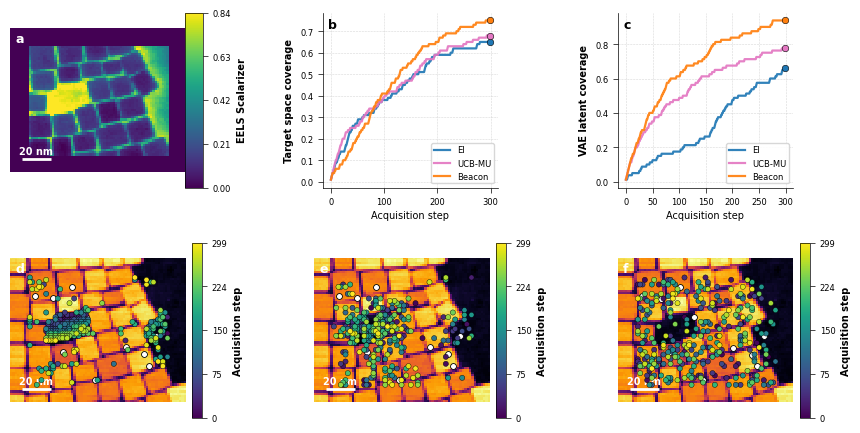

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── consistent palette ────────────────────────────────────────────────────────
colors = {"EI": "#1f77b4", "MU": "#e377c2", "Beacon": "#ff7f0e"}
labels_display = {"EI": "EI", "MU": "UCB-MU", "Beacon": "Beacon"}

plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.size":        7,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
})

# ── helpers ───────────────────────────────────────────────────────────────────
def add_scalebar(ax, pixel_size_nm, color="white", lw=2, fontsize=7,
                 bar_nm_fixed=None, fraction=0.25):
    h, w = ax.get_images()[0].get_array().shape[:2]
    bar_nm = (bar_nm_fixed if bar_nm_fixed is not None
              else round((w * fraction * pixel_size_nm) / 50) * 50)
    bar_px = bar_nm / pixel_size_nm
    x0, y0 = 0.06 * w, 0.90 * h
    ax.plot([x0, x0 + bar_px], [y0, y0], color=color, lw=lw, solid_capstyle="butt")
    label = f"{bar_nm:.0f} nm" if bar_nm < 1000 else f"{bar_nm/1000:.1f} µm"
    ax.text(x0 + bar_px / 2, y0 - 0.02 * h, label,
            color=color, ha="center", va="bottom",
            fontsize=fontsize, fontweight="bold")

def style_line_ax(ax):
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=6, width=0.5)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_linewidth(0.5)

def panel_label(ax, letter, color="black"):
    ax.text(0.03, 0.97, letter,
            transform=ax.transAxes,
            fontsize=9, fontweight="bold", color=color,
            va="top", ha="left")

# ── figure geometry ───────────────────────────────────────────────────────────
panel_sq  = 1.75   # all panels square
cbar_w    = 0.18   # colorbar width (panel a only)
hgap      = 1.2
vgap      = 0.55
lm, rm    = 0.45, 0.20
tm, bm    = 0.20, 0.55

# columns: img | cbar | gap | lineplot | gap | lineplot
col_w = [panel_sq, cbar_w, hgap, panel_sq, hgap, panel_sq]
row_h = [panel_sq, vgap, panel_sq]

fig_w = lm + sum(col_w) + rm
fig_h = tm + sum(row_h) + bm

fig = plt.figure(figsize=(fig_w, fig_h))

gs = gridspec.GridSpec(
    3, 6,
    figure=fig,
    width_ratios=col_w,
    height_ratios=row_h,
    left   = lm / fig_w,
    right  = 1 - rm / fig_w,
    top    = 1 - tm / fig_h,
    bottom = bm / fig_h,
    wspace = 0,
    hspace = 0,
)

# row 0
ax_a  = fig.add_subplot(gs[0, 0])    # (a) EELS scalarizer image
cax_a = fig.add_subplot(gs[0, 1])    # colorbar for (a)
ax_b  = fig.add_subplot(gs[0, 3])    # (b) target space novelty
ax_c  = fig.add_subplot(gs[0, 5])    # (c) VAE feature space novelty

# row 2 — trajectory images
ax_d  = fig.add_subplot(gs[2, 0])    # (d) EI  trajectory
ax_e  = fig.add_subplot(gs[2, 2])    # (e) UCB-MU trajectory  ← uses gap col
ax_f  = fig.add_subplot(gs[2, 4])    # (f) Beacon trajectory  ← uses gap col

# NOTE: ax_e and ax_f intentionally sit in the hgap columns (cols 2 & 4)
# to give 3 evenly spaced image panels across the full width.
# For pixel-perfect equal spacing, override with figure-level axes:
ax_d.remove(); ax_e.remove(); ax_f.remove()

traj_w = panel_sq / fig_w
traj_h = panel_sq / fig_h
traj_y = bm / fig_h
spacing = (1 - lm/fig_w - rm/fig_w - 3 * traj_w) / 2

ax_d = fig.add_axes([lm/fig_w,                          traj_y, traj_w, traj_h])
ax_e = fig.add_axes([lm/fig_w + traj_w + spacing,       traj_y, traj_w, traj_h])
ax_f = fig.add_axes([lm/fig_w + 2*traj_w + 2*spacing,   traj_y, traj_w, traj_h])

# ═══════════════════════════════════════════════════════════════════════════════
# (a) EELS scalarizer — image + colorbar
# ═══════════════════════════════════════════════════════════════════════════════
vmin_e, vmax_e = np.percentile(scalarizer_eels, [2, 98])
im_a = ax_a.imshow(scalarizer_eels, cmap="viridis",
                    interpolation="nearest", vmin=vmin_e, vmax=vmax_e)
ax_a.axis("off")
add_scalebar(ax_a, pixel_size_eels_nm, bar_nm_fixed=20)
panel_label(ax_a, "a", color="white")

cb_a = fig.colorbar(im_a, cax=cax_a)
cb_a.set_label("EELS Scalarizer", fontsize=7, fontweight="bold", labelpad=4)
cb_a.ax.tick_params(labelsize=6, width=0.5)
cb_a.outline.set_linewidth(0.5)
cb_a.set_ticks(np.linspace(vmin_e, vmax_e, 5))
cb_a.set_ticklabels([f"{v:.2f}" for v in np.linspace(vmin_e, vmax_e, 5)])

# ═══════════════════════════════════════════════════════════════════════════════
# (b) Target space novelty — ei, mu, bn
# ═══════════════════════════════════════════════════════════════════════════════
for name, cov in [("EI", coverage_eels["EI"]),
                  ("MU", coverage_eels["MU"]),
                  ("Beacon", coverage_eels["Beacon"])]:
    ax_b.plot(cov, color=colors[name], linewidth=1.6,
              alpha=0.92, label=labels_display[name])
    ax_b.scatter(len(cov) - 1, cov[-1],
                 color=colors[name], s=22,
                 edgecolors="k", linewidths=0.4, zorder=5)
    ax_b.legend(
        loc="lower right",          # change if it overlaps data
        frameon=True,
        framealpha=0.9,
        edgecolor="lightgray",
        fontsize=6,
        handlelength=2.0,
        borderpad=0.3
    )

ax_b.set_xlabel("Acquisition step", fontsize=7, labelpad=3)
ax_b.set_ylabel("Target space coverage", fontsize=7, fontweight="bold", labelpad=4)
style_line_ax(ax_b)
panel_label(ax_b, "b")

# ═══════════════════════════════════════════════════════════════════════════════
# (c) VAE feature space novelty — ei, mu, bn
# ═══════════════════════════════════════════════════════════════════════════════
for name, cov in [("EI", cover_ei_vae),
                  ("MU", cover_mu_vae),
                  ("Beacon", cover_bn_vae)]:
    ax_c.plot(cov, color=colors[name], linewidth=1.6,
              alpha=0.92, label=labels_display[name])
    ax_c.scatter(len(cov) - 1, cov[-1],
                 color=colors[name], s=22,
                 edgecolors="k", linewidths=0.4, zorder=5)
    ax_c.legend(
        loc="lower right",          # change if it overlaps data
        frameon=True,
        framealpha=0.9,
        edgecolor="lightgray",
        fontsize=6,
        handlelength=2.0,
        borderpad=0.3
    )

ax_c.set_xlabel("Acquisition step", fontsize=7, labelpad=3)
ax_c.set_ylabel("VAE latent coverage", fontsize=7, fontweight="bold", labelpad=4)
style_line_ax(ax_c)
panel_label(ax_c, "c")

# ═══════════════════════════════════════════════════════════════════════════════
# (d/e/f) Trajectory images — EI / UCB-MU / Beacon
# ═══════════════════════════════════════════════════════════════════════════════
traj_cases = [
    (ax_d, "d", acq_coords_ei,  seed_coords_ei,  t_ei),
    (ax_e, "e", acq_coords_mu,  seed_coords_mu,  t_mu),
    (ax_f, "f", acq_coords_bn,  seed_coords_bn,  t_bn),
]
t_max_eels = max(t_ei.max(), t_mu.max(), t_bn.max())

# pre-compute x positions of the 3 panels (same as before)
traj_w    = panel_sq / fig_w
traj_h    = panel_sq / fig_h
traj_y    = bm / fig_h
spacing   = (1 - lm/fig_w - rm/fig_w - 3 * traj_w) / 2
cbar_pad  = 0.008   # gap between panel right edge and its colorbar
cbar_thick = 0.012  # colorbar width in figure coords

ax_x_positions = [
    lm/fig_w,
    lm/fig_w + traj_w + spacing,
    lm/fig_w + 2*traj_w + 2*spacing,
]

for i, (ax, letter, acq_coords, seed_coords, t) in enumerate(traj_cases):
    ty, tx   = acq_coords[:, 0],  acq_coords[:, 1]
    sdy, sdx = seed_coords[:, 0], seed_coords[:, 1]

    ax.imshow(img_eels, cmap="inferno", interpolation="nearest")
    ax.axis("off")
    add_scalebar(ax, pixel_size_eels_nm, bar_nm_fixed=20)

    ax.scatter(sdx, sdy,
               s=18, c="white", edgecolors="black", linewidths=0.6,
               marker="o", zorder=3)
    sc = ax.scatter(tx, ty,
                    c=t, cmap="viridis", vmin=0, vmax=t_max_eels,
                    s=14, marker="o", edgecolors="k", linewidths=0.3, zorder=4)
    panel_label(ax, letter, color="white")

    # individual colorbar — placed just right of each panel
    cax = fig.add_axes([
        ax_x_positions[i] + traj_w + cbar_pad,   # x: right edge of panel + pad
        traj_y,                                    # y: same bottom as panel
        cbar_thick,                                # width
        traj_h,                                    # height: full panel height
    ])
    cb = fig.colorbar(sc, cax=cax)
    cb.ax.tick_params(labelsize=6, width=0.5)
    cb.outline.set_linewidth(0.5)
    cb.set_ticks(np.linspace(0, t_max_eels, 5))
    cb.set_ticklabels([f"{v:.0f}" for v in np.linspace(0, t_max_eels, 5)])

    # only label the rightmost colorbar to avoid clutter
    # if i == 2:
    cb.set_label("Acquisition step", fontsize=7, fontweight="bold", labelpad=4)


# ── shared legend for line plots (b) and (c) ─────────────────────────────────
handles, lbls = ax_b.get_legend_handles_labels()
# fig.legend(handles, lbls,
#            loc="lower center", ncol=3,
#            bbox_to_anchor=(0.5, 0.01),
#            frameon=True, framealpha=0.9, edgecolor="lightgray",
#            fontsize=7, markerscale=1.2,
#            handlelength=2.0, columnspacing=1.5)

fig.savefig("fig6.pdf", dpi=600, bbox_inches="tight")
fig.savefig("fig6.png", dpi=600, bbox_inches="tight")
plt.show()